In [1]:
import subprocess
subprocess.run(['pip', 'install', 'rasterio'])

CompletedProcess(args=['pip', 'install', 'rasterio'], returncode=0)

In [2]:
import geopandas as gpd
import numpy as np
import rasterio
from rasterio.transform import from_bounds
from rasterio.features import rasterize
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print(f"Rasterio version: {rasterio.__version__}")
print("Tutto pronto!")

Rasterio version: 1.5.0
Tutto pronto!


In [3]:
# Carichiamo gli edifici
gdf = gpd.read_file(r"C:\Users\andre\OneDrive\Desktop\PARAMETRIC DESIGN\geojson_lnglat.json",
                    on_invalid="ignore")

# Puliamo e proiettiamo in metri (RD New - sistema olandese)
gdf_clean = gdf[gdf['Bouwjaar'] > 0].copy()
gdf_proj = gdf_clean.to_crs("EPSG:28992")

print(f"Edifici caricati: {len(gdf_proj)}")
print(f"CRS: {gdf_proj.crs}")
print(f"Bounds: {gdf_proj.total_bounds}")

Edifici caricati: 44517
CRS: EPSG:28992
Bounds: [110381.69319637 476804.22575109 135457.30279211 493756.70885872]


In [4]:
# Parametri del raster
risoluzione = 100  # 100 metri per pixel

bounds = gdf_proj.total_bounds
xmin, ymin, xmax, ymax = bounds

# Calcoliamo le dimensioni della griglia
cols = int((xmax - xmin) / risoluzione)
rows = int((ymax - ymin) / risoluzione)

print(f"Dimensioni raster: {cols} colonne x {rows} righe")
print(f"Ogni pixel = {risoluzione}x{risoluzione} metri")
print(f"Totale pixel: {cols * rows:,}")

Dimensioni raster: 250 colonne x 169 righe
Ogni pixel = 100x100 metri
Totale pixel: 42,250


In [5]:
# Creiamo la trasformazione geometrica del raster
transform = from_bounds(xmin, ymin, xmax, ymax, cols, rows)

# Prendiamo i centroidi degli edifici come punti
centroidi = gdf_proj.copy()
centroidi['geometry'] = centroidi.geometry.centroid

# Creiamo il raster contando gli edifici per pixel
shapes = [(geom, 1) for geom in centroidi.geometry if geom is not None]

raster = rasterize(
    shapes,
    out_shape=(rows, cols),
    transform=transform,
    fill=0,
    merge_alg='add',
    dtype='int32'
)

print(f"Raster creato!")
print(f"Valore massimo (pixel più denso): {raster.max()} edifici")
print(f"Valore medio (pixel non vuoti): {raster[raster > 0].mean():.1f} edifici")
print(f"Pixel con almeno un edificio: {(raster > 0).sum():,}")

AttributeError: 'str' object has no attribute 'value'

In [6]:
import numpy as np

# Creiamo il raster manualmente
raster = np.zeros((rows, cols), dtype=np.int32)

# Per ogni edificio, troviamo il pixel corrispondente
for geom in centroidi.geometry:
    if geom is not None:
        x, y = geom.x, geom.y
        col = int((x - xmin) / risoluzione)
        row = int((ymax - y) / risoluzione)
        if 0 <= col < cols and 0 <= row < rows:
            raster[row, col] += 1

print(f"Raster creato!")
print(f"Valore massimo (pixel più denso): {raster.max()} edifici")
print(f"Valore medio (pixel non vuoti): {raster[raster > 0].mean():.1f} edifici")
print(f"Pixel con almeno un edificio: {(raster > 0).sum():,}")

Raster creato!
Valore massimo (pixel più denso): 82 edifici
Valore medio (pixel non vuoti): 4.4 edifici
Pixel con almeno un edificio: 10,009


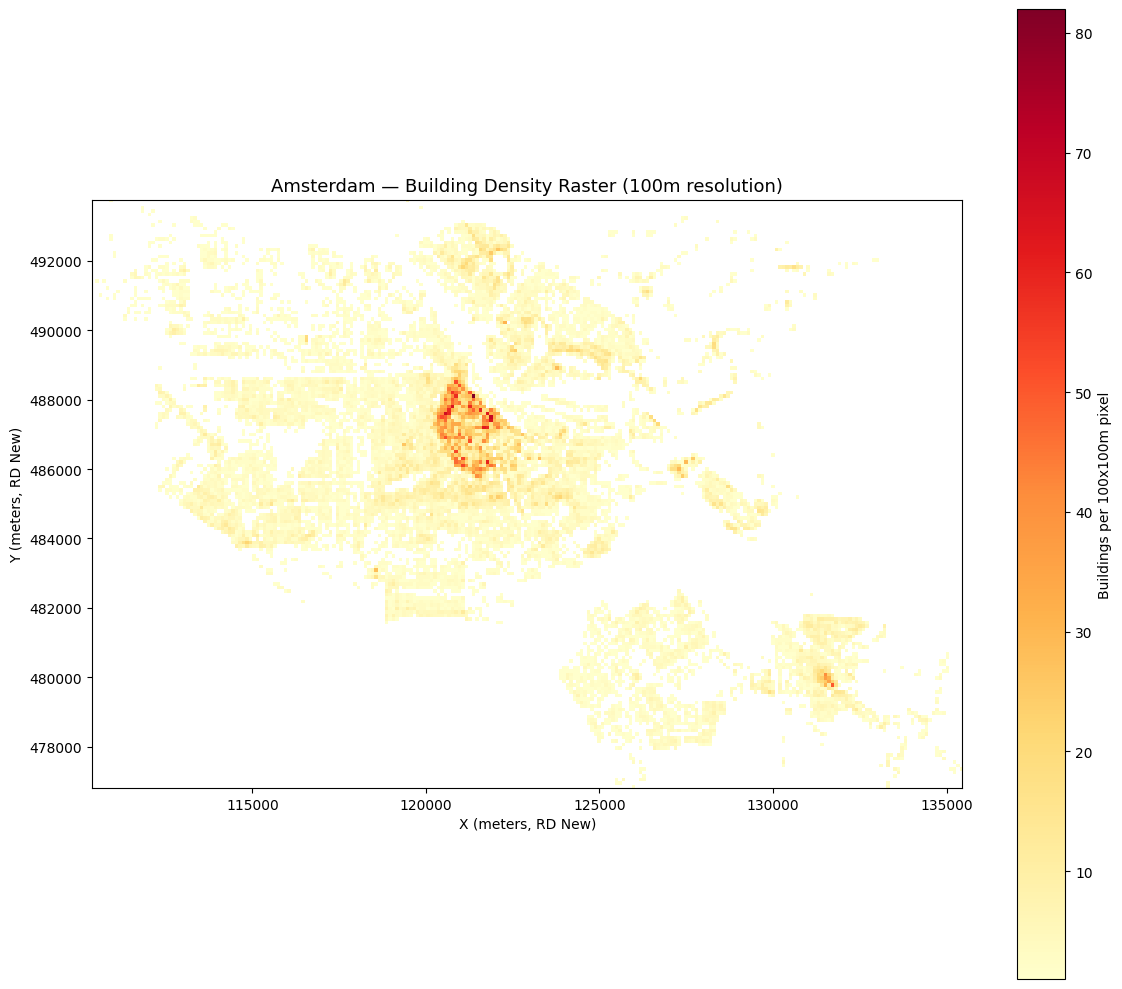

In [7]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Mascheriamo i pixel vuoti
raster_masked = np.ma.masked_where(raster == 0, raster)

# Visualizziamo
img = ax.imshow(
    raster_masked,
    cmap='YlOrRd',
    interpolation='nearest',
    extent=[xmin, xmax, ymin, ymax],
    aspect='equal'
)

plt.colorbar(img, ax=ax, label='Buildings per 100x100m pixel')
ax.set_title('Amsterdam — Building Density Raster (100m resolution)', fontsize=13)
ax.set_xlabel('X (meters, RD New)')
ax.set_ylabel('Y (meters, RD New)')
plt.tight_layout()
plt.savefig('amsterdam_density_raster.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
with rasterio.open(
    'amsterdam_density.tif',
    'w',
    driver='GTiff',
    height=rows,
    width=cols,
    count=1,
    dtype=raster.dtype,
    crs='EPSG:28992',
    transform=transform
) as dst:
    dst.write(raster, 1)

print("GeoTIFF salvato — amsterdam_density.tif")

GeoTIFF salvato — amsterdam_density.tif


In [9]:
with rasterio.open('amsterdam_density.tif') as src:
    print(f"Dimensioni: {src.width} x {src.height} pixel")
    print(f"CRS: {src.crs}")
    print(f"Risoluzione: {src.res} metri per pixel")
    print(f"Bounds: {src.bounds}")
    print(f"Numero di bande: {src.count}")
    
    # Rileggiamo i dati
    data = src.read(1)
    print(f"Valore massimo: {data.max()}")

Dimensioni: 250 x 169 pixel
CRS: EPSG:28992
Risoluzione: (100.3024383829328, 100.31055093273699) metri per pixel
Bounds: BoundingBox(left=110381.69319637297, bottom=476804.2257510854, right=135457.30279210617, top=493756.70885871793)
Numero di bande: 1
Valore massimo: 82
